# Verification Trials Analysis

`data/verification` 아래에서 `pet_name` 기준으로 대상을 찾아,
- facebank 이미지/메타 시각화
- trial outcome 4분면(TP/FN/FP/TN) 시각화
- score, pose, sharpness, 일자별 분포
를 확인하는 노트북입니다.

주의:
- 동일한 `pet_name`이 여러 `pet_id` 아래 존재할 수 있습니다. 이 경우 모두 검색 후 선택합니다.
- 4분면 시각화는 실제로 존재하는 outcome만 표시합니다. 예를 들어 TP/FN만 있으면 FP/TN은 생략합니다.


In [84]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Iterable

import math
import statistics

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image
from IPython.display import display, Markdown

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)


In [ ]:
# Parameters
VERIFICATION_ROOT = Path('/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification')
PET_NAME = 'rmm'
PET_ID = '0b8ae9a8-6c5f-48cf-a551-dd5e71fecf76'          # exact pet_id를 지정하고 싶으면 문자열로 설정
TRIAL_DATE = None      # 예: '2026-03-18' / None 이면 전체 날짜
MAX_FACEBANK_IMAGES = 12
MAX_IMAGES_PER_OUTCOME = 12
THUMB_SIZE = (220, 220)


In [86]:
def find_pet_dirs(root: Path, pet_name: str | None = None, pet_id: str | None = None):
    pets_root = root / 'pets'
    matches = []
    if not pets_root.exists():
        return matches
    for pet_id_dir in sorted(pets_root.iterdir()):
        if not pet_id_dir.is_dir():
            continue
        if pet_id and pet_id_dir.name != pet_id:
            continue
        for pet_name_dir in sorted(pet_id_dir.iterdir()):
            if not pet_name_dir.is_dir():
                continue
            if pet_name and pet_name_dir.name != pet_name:
                continue
            facebanks_dir = pet_name_dir / 'facebanks'
            trials_dir = pet_name_dir / 'trials'
            matches.append({
                'pet_id': pet_id_dir.name,
                'pet_name': pet_name_dir.name,
                'pet_dir': pet_name_dir,
                'facebanks_dir': facebanks_dir,
                'trials_dir': trials_dir,
            })
    return matches


def load_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))


def resolve_storage_path(path_str: str | None, verification_root: Path) -> Path | None:
    if not path_str:
        return None
    p = Path(path_str)
    if p.is_absolute():
        return p
    # stored trial image paths are typically relative like data/verification/...
    project_root = verification_root.parents[1]
    candidate = project_root / p
    if candidate.exists():
        return candidate
    candidate2 = verification_root / p
    if candidate2.exists():
        return candidate2
    return candidate


def collect_facebank_versions(facebanks_dir: Path):
    rows = []
    if not facebanks_dir.exists():
        return pd.DataFrame()
    for facebank_id_dir in sorted(facebanks_dir.iterdir()):
        if not facebank_id_dir.is_dir():
            continue
        for version_dir in sorted(facebank_id_dir.iterdir()):
            if not version_dir.is_dir():
                continue
            meta_path = version_dir / 'facebank_meta.json'
            hash_index_path = version_dir / 'hash_index.json'
            if not meta_path.exists():
                continue
            meta = load_json(meta_path)
            hash_index = load_json(hash_index_path) if hash_index_path.exists() else {}
            images_dir = version_dir / 'images'
            image_files = sorted([p for p in images_dir.glob('*') if p.is_file()]) if images_dir.exists() else []
            rows.append({
                'facebank_id': facebank_id_dir.name,
                'version': version_dir.name,
                'meta_path': str(meta_path),
                'hash_index_path': str(hash_index_path) if hash_index_path.exists() else None,
                'images_dir': str(images_dir),
                'image_count': len(image_files),
                'meta': meta,
                'hash_index': hash_index,
                'image_files': image_files,
            })
    return pd.DataFrame(rows)


def collect_trials(trials_dir: Path, trial_date: str | None = None):
    rows = []
    if not trials_dir.exists():
        return pd.DataFrame()
    date_dirs = [trials_dir / trial_date] if trial_date else sorted([p for p in trials_dir.iterdir() if p.is_dir()])
    for date_dir in date_dirs:
        if not date_dir.exists() or not date_dir.is_dir():
            continue
        for json_path in sorted(date_dir.glob('*.json')):
            payload = load_json(json_path)
            payload['_json_path'] = str(json_path)
            payload['_date'] = date_dir.name
            image_path = payload.get('image_path')
            resolved_image_path = resolve_storage_path(image_path, VERIFICATION_ROOT)
            payload['_resolved_image_path'] = str(resolved_image_path) if resolved_image_path else None
            payload['_image_exists'] = bool(resolved_image_path) and resolved_image_path.exists()
            rows.append(payload)
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)
    if 'score' in df.columns:
        df['score'] = pd.to_numeric(df['score'], errors='coerce')
    if 'threshold' in df.columns:
        df['threshold'] = pd.to_numeric(df['threshold'], errors='coerce')
    if 'sharpness' in df.columns:
        df['sharpness'] = pd.to_numeric(df['sharpness'], errors='coerce')
    else:
        df['sharpness'] = pd.Series([float('nan')] * len(df), dtype='float64')
    return df.sort_values('timestamp').reset_index(drop=True)


def open_thumb(path: Path, thumb_size=(220, 220)):
    img = Image.open(path).convert('RGB')
    img.thumbnail(thumb_size)
    return img


In [87]:
matches = find_pet_dirs(VERIFICATION_ROOT, pet_name=PET_NAME, pet_id=PET_ID)
if not matches:
    raise FileNotFoundError(f'No pet directories found for PET_NAME={PET_NAME!r}, PET_ID={PET_ID!r}')

match_df = pd.DataFrame([{k: str(v) if isinstance(v, Path) else v for k, v in row.items() if k not in ('pet_dir', 'facebanks_dir', 'trials_dir')} for row in matches])
display(Markdown('## Matched pet directories'))
display(match_df)

selected = matches[0]
display(Markdown(f"### Selected pet: `{selected['pet_name']}` (`{selected['pet_id']}`)"))
selected


## Matched pet directories

,pet_id,pet_name
0,70a9ff3b-07c2-4f49-a4b9-6c4250d28d15,rmm


### Selected pet: `rmm` (`70a9ff3b-07c2-4f49-a4b9-6c4250d28d15`)

{'pet_id': '70a9ff3b-07c2-4f49-a4b9-6c4250d28d15',
 'pet_name': 'rmm',
 'pet_dir': PosixPath('/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm'),
 'facebanks_dir': PosixPath('/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/facebanks'),
 'trials_dir': PosixPath('/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials')}

In [88]:
facebank_df = collect_facebank_versions(selected['facebanks_dir'])
trials_df = collect_trials(selected['trials_dir'], trial_date=TRIAL_DATE)

display(Markdown('## Summary'))
print('pet_id      :', selected['pet_id'])
print('pet_name    :', selected['pet_name'])
print('facebanks   :', len(facebank_df))
print('trials      :', len(trials_df))
if not trials_df.empty:
    print('date range   :', trials_df['timestamp'].min(), '->', trials_df['timestamp'].max())
    print('outcomes     :', trials_df['outcome'].value_counts().to_dict())
    print('image exists :', int(trials_df['_image_exists'].sum()), '/', len(trials_df))


## Summary

pet_id      : 70a9ff3b-07c2-4f49-a4b9-6c4250d28d15
pet_name    : rmm
facebanks   : 1
trials      : 15
date range   : 2026-03-18 09:34:51.097000+00:00 -> 2026-03-18 09:35:25.743000+00:00
outcomes     : {'TP': 15}
image exists : 15 / 15


## Facebank versions

,facebank_id,version,image_count,meta_path,hash_index_path
0,c1eee5d5-919d-4497-bb5d-7791264faa43,v1,5,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/facebanks/...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/facebanks/...


### Facebank `c1eee5d5-919d-4497-bb5d-7791264faa43` / `v1`

,pet_id,pet_name,facebank_id,facebank_version,created_at,device_id,model_version,embedding_dim,threshold
0,70a9ff3b-07c2-4f49-a4b9-6c4250d28d15,rmm,c1eee5d5-919d-4497-bb5d-7791264faa43,1,2026-03-18T09:34:52.110697+00:00,None,None,None,None


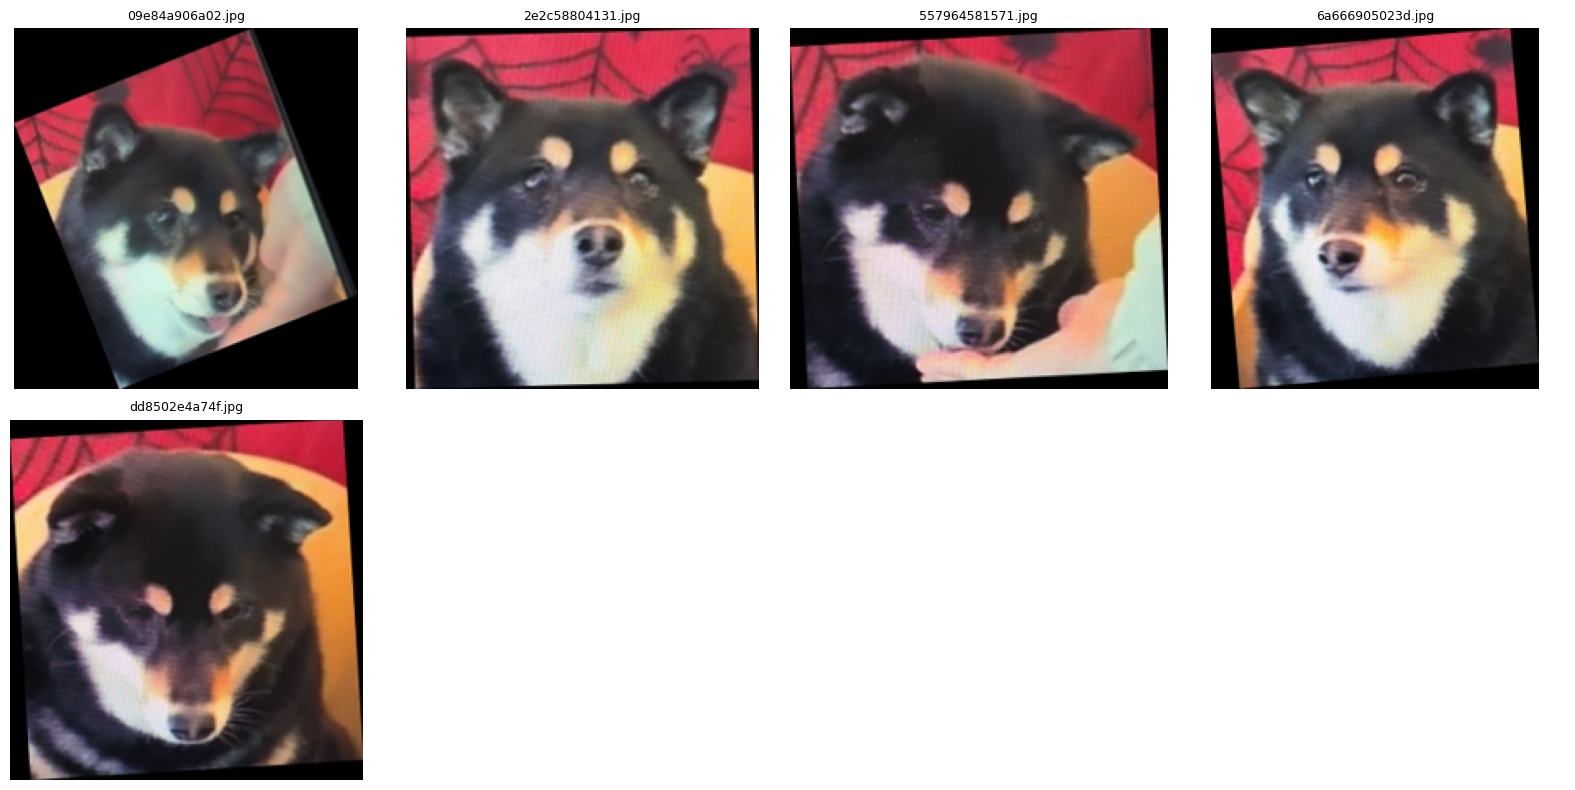

In [89]:
display(Markdown('## Facebank versions'))
if facebank_df.empty:
    display(Markdown('_No facebank data found._'))
else:
    fb_view = facebank_df[['facebank_id', 'version', 'image_count', 'meta_path', 'hash_index_path']]
    display(fb_view)

    for _, row in facebank_df.iterrows():
        display(Markdown(f"### Facebank `{row['facebank_id']}` / `{row['version']}`"))
        meta = row['meta']
        display(pd.DataFrame([meta]))
        images = row['image_files'][:MAX_FACEBANK_IMAGES]
        if not images:
            display(Markdown('_No facebank images found._'))
            continue

        cols = min(4, len(images))
        rows_n = math.ceil(len(images) / cols)
        fig, axes = plt.subplots(rows_n, cols, figsize=(4*cols, 4*rows_n))
        if not isinstance(axes, Iterable) or not hasattr(axes, 'ravel'):
            axes = [axes]
        axes = list(axes.ravel())
        for ax, img_path in zip(axes, images):
            ax.imshow(open_thumb(img_path, THUMB_SIZE))
            ax.set_title(img_path.name, fontsize=9)
            ax.axis('off')
        for ax in axes[len(images):]:
            ax.axis('off')
        plt.tight_layout()
        plt.show()


In [90]:
display(Markdown('## Trials table'))
if trials_df.empty:
    display(Markdown('_No trials found._'))
else:
    cols = [c for c in ['trial_id', 'timestamp', 'outcome', 'score', 'threshold', 'sharpness', 'pose', 'is_success', 'user_feedback', 'image_path', '_resolved_image_path', '_image_exists'] if c in trials_df.columns]
    display(trials_df[cols])


## Trials table

,trial_id,timestamp,outcome,score,threshold,sharpness,pose,is_success,user_feedback,image_path,_resolved_image_path,_image_exists
0,be5c208d-0212-42f5-b146-a64e657e4baf,2026-03-18 09:34:51.097000+00:00,TP,0.848596,0.75,NaN,unknown,True,True,data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/2026-03-18/be5c208d-0212-42f5-b146-a64e657e4b...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/202...,True
1,5d055635-ad38-47d3-bcf5-d19a585317eb,2026-03-18 09:34:54.750000+00:00,TP,0.840829,0.75,NaN,unknown,True,True,data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/2026-03-18/5d055635-ad38-47d3-bcf5-d19a585317...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/202...,True
2,0f9ae7a8-a653-4564-8f7d-4b049af70534,2026-03-18 09:34:57.089000+00:00,TP,0.776234,0.75,NaN,unknown,True,True,data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/2026-03-18/0f9ae7a8-a653-4564-8f7d-4b049af705...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/202...,True
3,1d0f04da-f3b0-423c-b812-bcc2e237f571,2026-03-18 09:35:03.214000+00:00,TP,0.826247,0.75,NaN,unknown,True,True,data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/2026-03-18/1d0f04da-f3b0-423c-b812-bcc2e237f5...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/202...,True
4,32dbe165-aba5-45fa-a8df-d5d21c89ba7d,2026-03-18 09:35:06.867000+00:00,TP,0.891767,0.75,NaN,unknown,True,True,data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/2026-03-18/32dbe165-aba5-45fa-a8df-d5d21c89ba...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/202...,True
5,a0756c9f-ef80-48f5-96ec-8e389c5dd0bf,2026-03-18 09:35:07.882000+00:00,TP,0.838361,0.75,NaN,unknown,True,True,data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/2026-03-18/a0756c9f-ef80-48f5-96ec-8e389c5dd0...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/202...,True
6,943e0752-680f-4807-9b32-7739249f3855,2026-03-18 09:35:10.475000+00:00,TP,0.866684,0.75,NaN,unknown,True,True,data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/2026-03-18/943e0752-680f-4807-9b32-7739249f38...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/202...,True
7,cce2f437-af95-4daa-9a73-f8e477e66309,2026-03-18 09:35:11.896000+00:00,TP,0.871179,0.75,NaN,unknown,True,True,data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/2026-03-18/cce2f437-af95-4daa-9a73-f8e477e663...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/202...,True
8,583919ad-8da8-4025-be3c-ac901b57accd,2026-03-18 09:35:13.592000+00:00,TP,0.817401,0.75,NaN,unknown,True,True,data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/2026-03-18/583919ad-8da8-4025-be3c-ac901b57ac...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/202...,True
9,712edbb4-b147-449d-9889-cd597832b683,2026-03-18 09:35:15.355000+00:00,TP,0.766311,0.75,NaN,unknown,True,True,data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/2026-03-18/712edbb4-b147-449d-9889-cd597832b6...,/workspace/PoC/dogface_fastapi_poc_qdrant/data/verification/pets/70a9ff3b-07c2-4f49-a4b9-6c4250d28d15/rmm/trials/202...,True


In [91]:
display(Markdown('## Outcome summary'))
if not trials_df.empty:
    agg_spec = {
        'count': ('trial_id', 'count'),
        'score_mean': ('score', 'mean'),
        'score_min': ('score', 'min'),
        'score_max': ('score', 'max'),
        'threshold_mean': ('threshold', 'mean'),
    }
    if 'sharpness' in trials_df.columns:
        agg_spec['sharpness_mean'] = ('sharpness', 'mean')
    summary = trials_df.groupby('outcome').agg(**agg_spec).reset_index().sort_values('outcome')
    display(summary)

    pose_summary = trials_df.groupby(['outcome', 'pose']).size().reset_index(name='count').sort_values(['outcome', 'count'], ascending=[True, False])
    display(Markdown('### Pose counts'))
    display(pose_summary)


## Outcome summary

,outcome,count,score_mean,score_min,score_max,threshold_mean,sharpness_mean
0,TP,15,0.812006,0.75561,0.891767,0.75,NaN


### Pose counts

,outcome,pose,count
0,TP,unknown,15


## Trial quadrants

### 1사분면: TP (12 images shown)

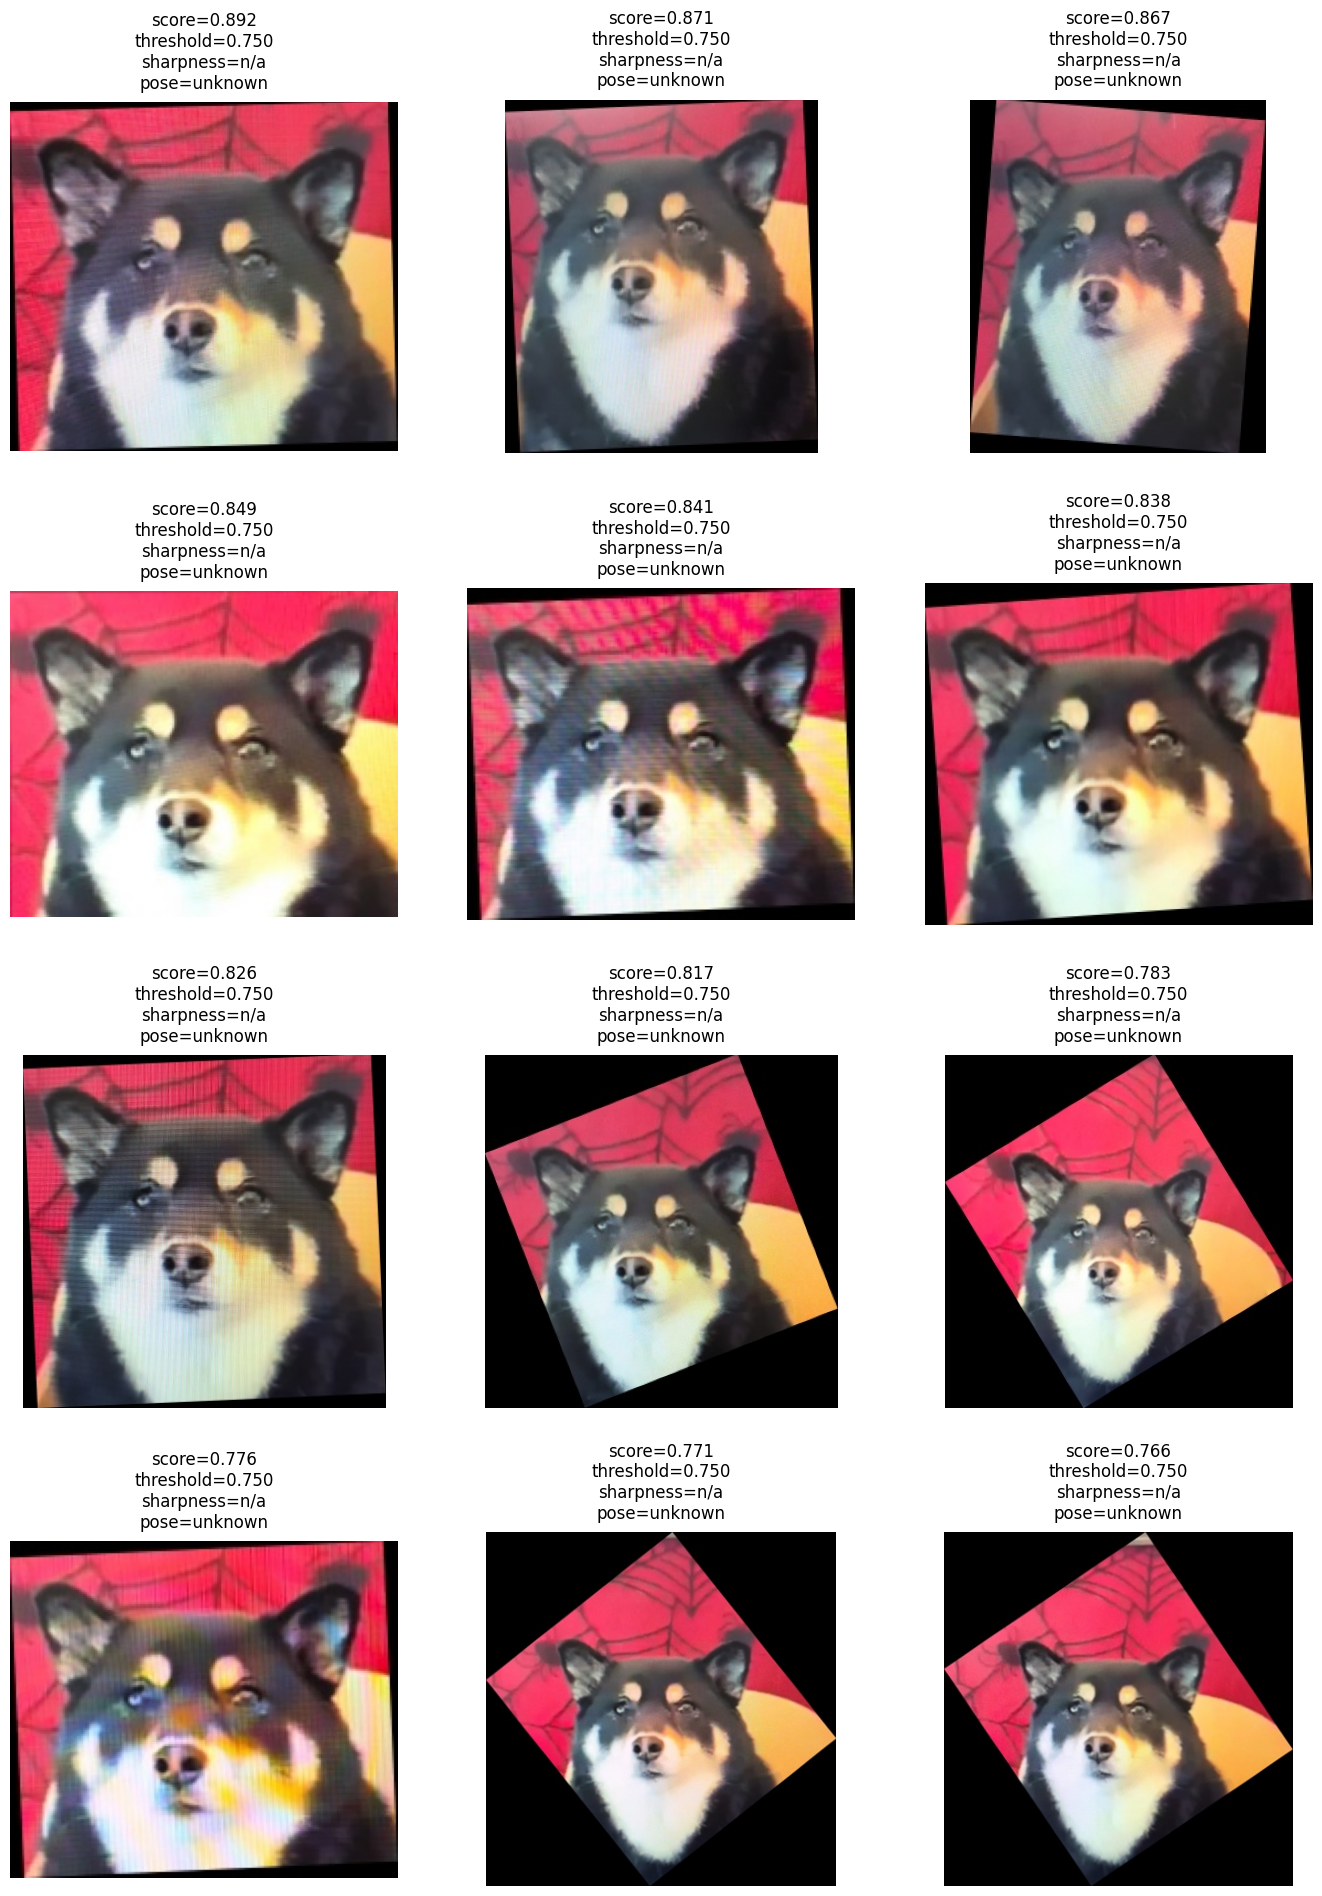

In [92]:
OUTCOME_QUADRANTS = [
    ('TP', '1사분면: TP'),
    ('FN', '2사분면: FN'),
    ('FP', '3사분면: FP'),
    ('TN', '4사분면: TN'),
]


def render_outcome_gallery(df: pd.DataFrame, max_images_per_outcome: int = 12):
    present = [(key, title) for key, title in OUTCOME_QUADRANTS if key in set(df['outcome'].dropna())]
    if not present:
        display(Markdown('_No outcome-labeled trials to visualize._'))
        return

    display(Markdown('## Trial quadrants'))
    for outcome_key, title in present:
        subset = df[df['outcome'] == outcome_key].copy()
        subset = subset.sort_values(['score', 'timestamp'], ascending=[False, True]).head(max_images_per_outcome)
        display(Markdown(f'### {title} ({len(subset)} images shown)'))

        cols = min(3, len(subset))
        rows_n = math.ceil(len(subset) / cols)
        fig, axes = plt.subplots(rows_n, cols, figsize=(5.6*cols, 5.8*rows_n))
        if not isinstance(axes, Iterable) or not hasattr(axes, 'ravel'):
            axes = [axes]
        axes = list(axes.ravel())

        for ax, (_, row) in zip(axes, subset.iterrows()):
            image_path = Path(row['_resolved_image_path']) if pd.notna(row.get('_resolved_image_path')) else None
            if image_path and image_path.exists():
                ax.imshow(open_thumb(image_path, (360, 360)))
            else:
                ax.text(0.5, 0.5, 'image missing', ha='center', va='center', fontsize=14)
            score = row.get('score')
            threshold = row.get('threshold')
            sharpness = row.get('sharpness')
            pose = row.get('pose')
            title_lines = [
                f"score={score:.3f}" if pd.notna(score) else 'score=n/a',
                f"threshold={threshold:.3f}" if pd.notna(threshold) else 'threshold=n/a',
                f"sharpness={sharpness:.2f}" if pd.notna(sharpness) else 'sharpness=n/a',
                f"pose={pose}" if pd.notna(pose) else 'pose=n/a',
            ]
            ax.set_title('\n'.join(title_lines), fontsize=12, pad=10)
            ax.axis('off')

        for ax in axes[len(subset):]:
            ax.axis('off')
        fig.subplots_adjust(top=0.88, hspace=0.35, wspace=0.18)
        plt.show()


if not trials_df.empty:
    render_outcome_gallery(trials_df, MAX_IMAGES_PER_OUTCOME)


## Score distribution

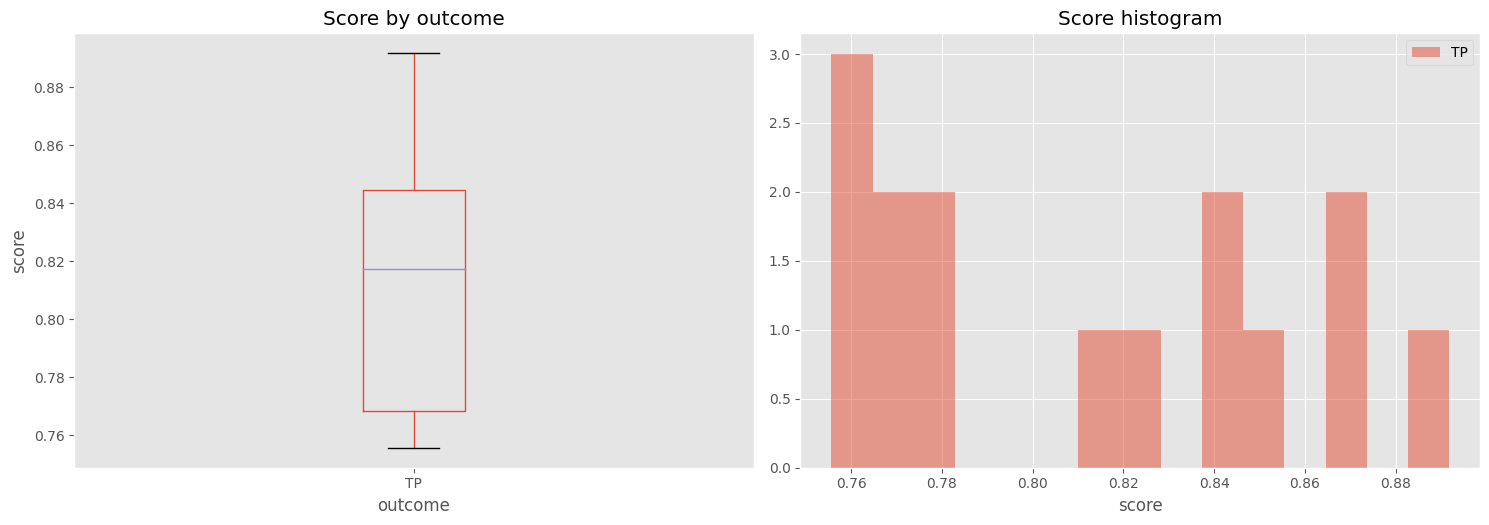

In [93]:
if not trials_df.empty:
    display(Markdown('## Score distribution'))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    outcome_order = [k for k, _ in OUTCOME_QUADRANTS if k in set(trials_df['outcome'].dropna())]
    trials_df.boxplot(column='score', by='outcome', ax=axes[0], grid=False)
    axes[0].set_title('Score by outcome')
    axes[0].set_xlabel('outcome')
    axes[0].set_ylabel('score')

    for outcome in outcome_order:
        subset = trials_df[trials_df['outcome'] == outcome]
        axes[1].hist(subset['score'].dropna(), bins=15, alpha=0.5, label=outcome)
    axes[1].set_title('Score histogram')
    axes[1].set_xlabel('score')
    axes[1].legend()

    plt.suptitle('')
    plt.tight_layout()
    plt.show()


## Time series / threshold / sharpness

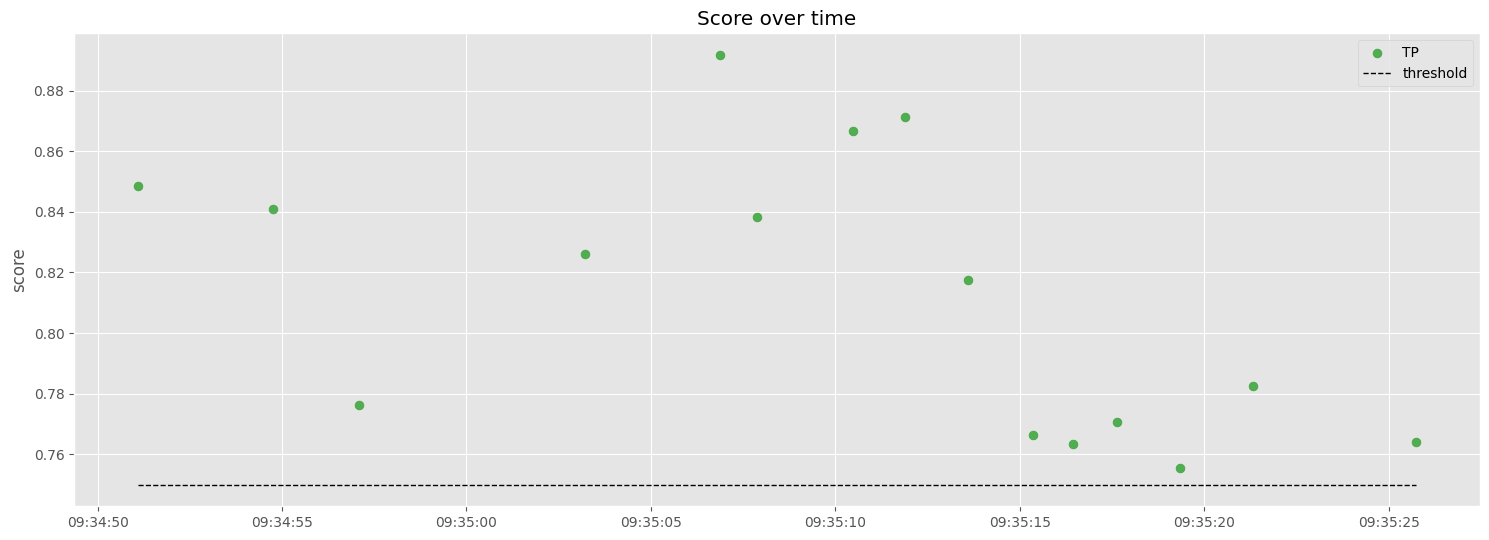

In [94]:
if not trials_df.empty:
    display(Markdown('## Time series / threshold / sharpness'))
    has_sharpness = 'sharpness' in trials_df.columns and trials_df['sharpness'].notna().any()
    fig, axes = plt.subplots(2 if has_sharpness else 1, 1, figsize=(15, 5.5 if not has_sharpness else 9.5), sharex=True)
    if not isinstance(axes, Iterable):
        axes = [axes]

    ax0 = axes[0]
    for outcome, color in [('TP', '#2ca02c'), ('FN', '#1f77b4'), ('FP', '#d62728'), ('TN', '#7f7f7f')]:
        subset = trials_df[trials_df['outcome'] == outcome]
        if subset.empty:
            continue
        ax0.scatter(subset['timestamp'], subset['score'], label=outcome, alpha=0.8, s=40, color=color)
    if trials_df['threshold'].notna().any():
        ax0.plot(trials_df['timestamp'], trials_df['threshold'], color='black', linestyle='--', linewidth=1.0, label='threshold')
    ax0.set_title('Score over time')
    ax0.set_ylabel('score')
    ax0.legend()

    if has_sharpness and len(axes) > 1:
        ax1 = axes[1]
        ax1.plot(trials_df['timestamp'], trials_df['sharpness'], marker='o', linestyle='-', color='#9467bd')
        ax1.set_title('Sharpness over time')
        ax1.set_ylabel('sharpness')

    plt.tight_layout()
    plt.show()


In [95]:
if not trials_df.empty and 'sharpness' in trials_df.columns and trials_df['sharpness'].notna().any():
    display(Markdown('## Sharpness vs score'))
    fig, ax = plt.subplots(figsize=(7, 6))
    for outcome, color in [('TP', '#2ca02c'), ('FN', '#1f77b4'), ('FP', '#d62728'), ('TN', '#7f7f7f')]:
        subset = trials_df[trials_df['outcome'] == outcome]
        if subset.empty or subset['sharpness'].notna().sum() == 0:
            continue
        ax.scatter(subset['sharpness'], subset['score'], label=outcome, alpha=0.8, s=45, color=color)
    ax.set_xlabel('sharpness')
    ax.set_ylabel('score')
    ax.set_title('Sharpness vs score')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [96]:
display(Markdown('## Useful derived metrics'))
if not trials_df.empty:
    total = len(trials_df)
    tp = int((trials_df['outcome'] == 'TP').sum())
    fn = int((trials_df['outcome'] == 'FN').sum())
    fp = int((trials_df['outcome'] == 'FP').sum())
    tn = int((trials_df['outcome'] == 'TN').sum())

    metrics = {
        'total_trials': total,
        'tp': tp,
        'fn': fn,
        'fp': fp,
        'tn': tn,
        'precision': tp / (tp + fp) if (tp + fp) else None,
        'recall': tp / (tp + fn) if (tp + fn) else None,
        'accuracy': (tp + tn) / total if total else None,
        'score_mean': trials_df['score'].mean() if 'score' in trials_df else None,
        'score_std': trials_df['score'].std() if 'score' in trials_df else None,
        'sharpness_mean': trials_df['sharpness'].mean() if 'sharpness' in trials_df.columns and trials_df['sharpness'].notna().any() else None,
    }
    display(pd.DataFrame([metrics]).T.rename(columns={0: 'value'}))


## Useful derived metrics

,value
total_trials,15
tp,15
fn,0
fp,0
tn,0
precision,1.0
recall,1.0
accuracy,1.0
score_mean,0.812006
score_std,0.046073
